<a href="https://colab.research.google.com/github/Dkaushani/italian-macro-energy-analysis/blob/main/Italinan_macro_energy_analysis_visualisation%20_using%20SQL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

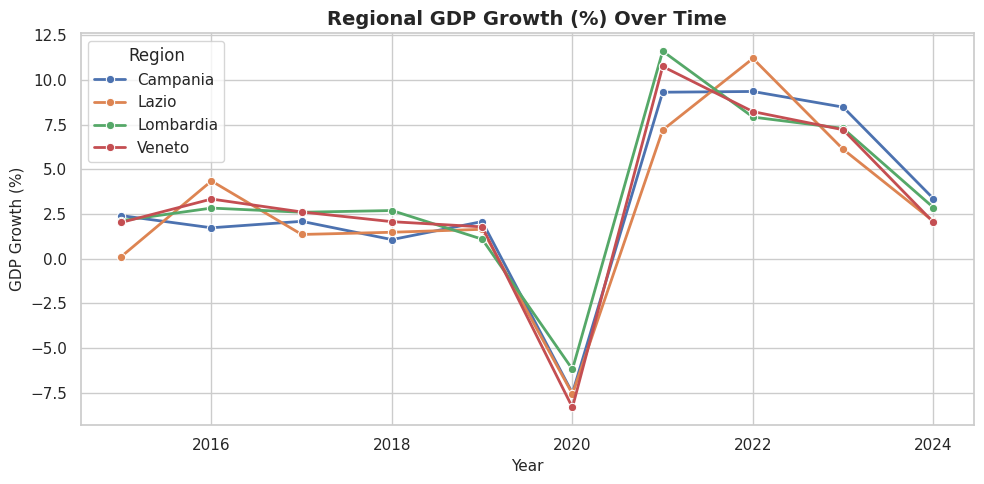

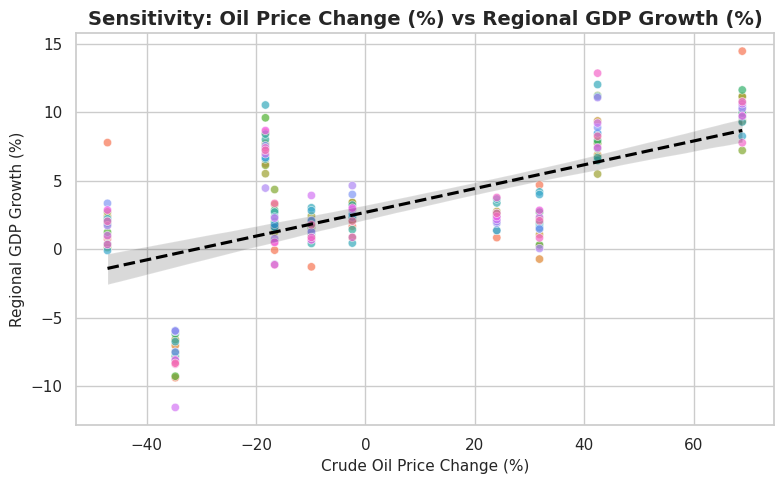

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Read the exported CSV file directly
df = pd.read_csv('mm.csv')

# 2. Sort data and compute YoY growth rates (replicating LAG window functions)
df = df.sort_values(by=['region_name', 'year'])

df['prev_gdp'] = df.groupby('region_name')['gdp_value'].shift(1)
df['gdp_growth_pct'] = ((df['gdp_value'] - df['prev_gdp']) / df['prev_gdp']) * 100

df['prev_oil'] = df.groupby('region_name')['crude_oil_price'].shift(1)
df['oil_price_change_pct'] = ((df['crude_oil_price'] - df['prev_oil']) / df['prev_oil']) * 100

# Drop the first year (2014) where LAG values are NaN
clean_df = df.dropna(subset=['gdp_growth_pct', 'oil_price_change_pct']).copy()

# 3. Plot 1: Regional GDP Growth Over Time
plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")
key_regions = ['Lombardia', 'Lazio', 'Veneto', 'Campania']
sns.lineplot(
    data=clean_df[clean_df['region_name'].isin(key_regions)],
    x='year',
    y='gdp_growth_pct',
    hue='region_name',
    marker='o',
    linewidth=2
)
plt.title('Regional GDP Growth (%) Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=11)
plt.ylabel('GDP Growth (%)', fontsize=11)
plt.legend(title='Region')
plt.tight_layout()
plt.savefig('gdp_growth_trend.png', dpi=300)
plt.show()

# 4. Plot 2: Regional Sensitivity Curve (Oil Shock vs GDP Growth)
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=clean_df,
    x='oil_price_change_pct',
    y='gdp_growth_pct',
    hue='region_name',
    legend=False,
    alpha=0.7
)
sns.regplot(
    data=clean_df,
    x='oil_price_change_pct',
    y='gdp_growth_pct',
    scatter=False,
    color='black',
    line_kws={'linestyle': '--'}
)
plt.title('Sensitivity: Oil Price Change (%) vs Regional GDP Growth (%)', fontsize=14, fontweight='bold')
plt.xlabel('Crude Oil Price Change (%)', fontsize=11)
plt.ylabel('Regional GDP Growth (%)', fontsize=11)
plt.tight_layout()
plt.savefig('oil_vs_gdp_resilience.png', dpi=300)
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')